<a href="https://colab.research.google.com/github/Anyaporwal/Bone-Fracture-Detection/blob/main/A2_20_AnyaPorwal_Practi10_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Name : Anya Porwal
## Roll No. : A2 -20
## Branch/Year : CSE(DS)/3rd yr (section A)
## Course : Deep Learning-1 Lab
## Practical No. 10 (Project Work)

# Topic: Bone Fracture Detection - Detects fractures from X-ray images
---
Dataset used : https://www.kaggle.com/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data

Model used : CNN model ( that classifies X-ray images into - Fractured/Normal)

---

In [ ]:
import os # Used to interact with system environment variables

# Setting Kaggle username as an environment variable
os.environ['KAGGLE_USERNAME'] = "anap12"
# Setting Kaggle API key (token)
os.environ['KAGGLE_KEY'] = "KGAT_aa649f07b8c4d626ee241cfeefe69e58"

In [ ]:
!pip install kaggle

In [ ]:
# Download Dataset from kaggle
!kaggle datasets download -d bmadushanirodrigo/fracture-multi-region-x-ray-data

Dataset URL: https://www.kaggle.com/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data
License(s): ODC Public Domain Dedication and Licence (PDDL)
fracture-multi-region-x-ray-data.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip fracture-multi-region-x-ray-data.zip

Streaming output truncated to the last 5000 lines.
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2-rotated3 (1).jpg  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2-rotated3-rotated1 (1).jpg  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2-rotated3-rotated1.jpg  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2-rotated3.jpg  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2.jpg  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated3 (1).jpg  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/

In [ ]:
import os # Used to interact with the operating system (file paths, environment variables, etc.)
import tensorflow as tf # Deep learning library used to build and train neural networks
from tensorflow.keras import layers, models # layers - used to create CNN layers (Conv2D, Dense, etc.)
# models - used to build the overall neural network architecture
import matplotlib.pyplot as plt # Used for plotting graphs (like training accuracy and loss)

In [ ]:
img_size = 224 # Resize all images to 224x224 pixels (standard size for CNN models)
batch_size = 32 # Number of images processed at once during training

# Load training dataset from directory
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train",
    image_size=(img_size, img_size),
    batch_size=batch_size
)

# Load validation dataset (used to evaluate model performance)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/val",
    image_size=(img_size, img_size),
    batch_size=batch_size
)

class_names = train_ds.class_names

Found 9246 files belonging to 2 classes.
Found 829 files belonging to 2 classes.


In [ ]:
# Print the class names of the dataset
print("Classes:", class_names)

Classes: ['fractured', 'not fractured']


In [ ]:
from tensorflow.keras import layers   # Import layers like Rescaling
import tensorflow as tf               # Import TensorFlow for dataset operations

# Create normalization layer
# This converts pixel values from (0–255) -> (0–1)
normalization_layer = layers.Rescaling(1./255)

# Apply normalization to training dataset
# x = images, y = labels
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))

# Apply normalization to validation dataset
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# Ignore corrupted/broken images in training dataset
# If any image cannot be read, TensorFlow skips it instead of crashing
train_ds = train_ds.apply(tf.data.experimental.ignore_errors())

# Ignore corrupted/broken images in validation dataset
val_ds = val_ds.apply(tf.data.experimental.ignore_errors())

Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


In [ ]:
from tensorflow.keras import models

model = models.Sequential([

    # First Convolution Layer
    # 32 filters of size 3x3 extract basic features like edges and bone boundaries
    # input_shape=(224,224,3) means
    # ReLU activation -> non-linearity and speeds up training
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),

    # MaxPooling layer
    # Keeps most important features and reduces computation
    layers.MaxPooling2D(),

    # Second Convolution Layer
    # 64 filters learn more complex features like shapes and fracture patterns
    layers.Conv2D(64, (3,3), activation='relu'),

    # MaxPooling again to further reduce dimensions
    # Helps prevent overfitting and improves speed
    layers.MaxPooling2D(),

    # Third Convolution Layer
    # 128 filters learn deeper features like bone structure irregularities
    # This layer captures high-level fracture details
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    # Flatten layer converts 2D feature maps into 1D vector
    # Required before feeding into fully connected layers
    layers.Flatten(),

    # Fully connected Dense layer with 128 neurons
    # Learns high-level patterns for classification
    layers.Dense(128, activation='relu'),

    # Dropout layer randomly disables 50% neurons during training
    # Prevents overfitting and improves generalization
    layers.Dropout(0.5),

    # Output layer with 1 neuron for binary classification
    # Sigmoid activation outputs probability between 0 and 1
    # Used to classify: fracture vs not fracture
    layers.Dense(1, activation='sigmoid')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile the CNN model
model.compile(

    # Optimizer controls how model updates weights during training
    optimizer='adam',

    # Loss function measures how wrong the predictions are
    # binary_crossentropy is used for binary classification (fracture / not fracture)
    # Model tries to minimize this loss during training
    loss='binary_crossentropy',

    # Metrics define what to display during training
    # accuracy shows percentage of correct predictions
    metrics=['accuracy']
)

In [ ]:
# Ignore corrupted images and repeat dataset indefinitely
# ignore_errors() -> skips broken images instead of crashing
# repeat() -> repeats dataset forever
train_ds = train_ds.apply(tf.data.experimental.ignore_errors()).repeat()

# Same processing for validation dataset
# Ensures validation data also repeats and skips bad images
val_ds = val_ds.apply(tf.data.experimental.ignore_errors()).repeat()

# AUTOTUNE automatically optimizes performance
# TensorFlow decides best number of batches to load in parallel
AUTOTUNE = tf.data.AUTOTUNE

# Prefetch loads next batch while model is training
# This speeds up training and reduces idle GPU/CPU time
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)

# Prefetch validation dataset for faster validation
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [ ]:
# Train the CNN model
history = model.fit(

    train_ds,
    # Training dataset used for learning model weights

    validation_data=val_ds,
    # Validation dataset used to evaluate model after each epoch

    epochs=2,
    # Number of complete passes through the training dataset
    # Model will train 3 times over the data

    steps_per_epoch=150,
    # Number of batches processed in one epoch
    # Since dataset is repeated (infinite), we manually define stopping point
    # 150 steps = 150 batches per epoch

    validation_steps=80
    # Number of validation batches used after each epoch
    # Stops validation after 80 batches instead of running forever
)

Epoch 1/2
150/150 ━━━━━━━━━━━━━━━━━━━━ 577s 4s/step - accuracy: 0.7802 - loss: 0.4608 - val_accuracy: 0.8751 - val_loss: 0.2967
Epoch 2/2
150/150 ━━━━━━━━━━━━━━━━━━━━ 581s 4s/step - accuracy: 0.9229 - loss: 0.1973 - val_accuracy: 0.9036 - val_loss: 0.2362


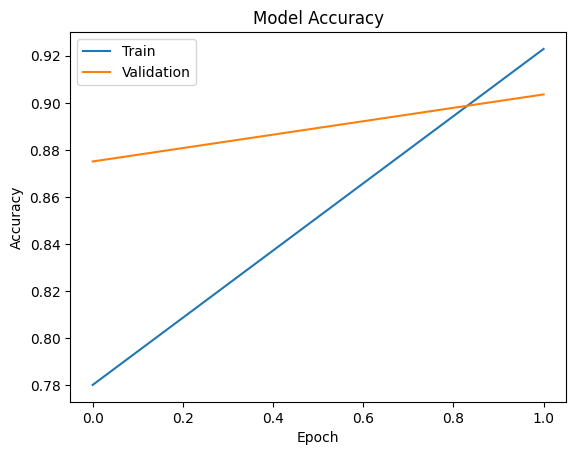

In [ ]:
import matplotlib.pyplot as plt # Import matplotlib library for plotting graphs

# Plot training accuracy values stored during model training
plt.plot(history.history['accuracy'])

# Plot validation accuracy values
# This shows how well model performs on unseen validation data
plt.plot(history.history['val_accuracy'])

# Add legend to distinguish the two lines
# Train = training accuracy
# Validation = validation accuracy
plt.legend(['Train', 'Validation'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


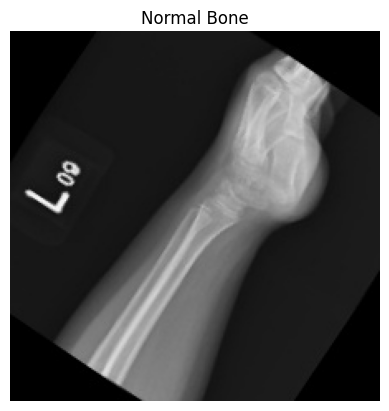

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

#  path to an existing image within the unzipped dataset
img_path = "/content/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/not fractured/57-rotated1-rotated3.jpg"

# Load image
img = image.load_img(img_path, target_size=(224,224))

# Convert to array
img_array = image.img_to_array(img) / 255.0

# Expand dimension
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

# Show image
plt.imshow(img)
plt.axis("off")

# Print prediction on image
if prediction[0][0] > 0.5:
    plt.title("Fracture Detected")
else:
    plt.title("Normal Bone")

plt.show()